# Demo: IFFAR Autoregressive Inference

In [22]:
from __future__ import annotations
import json
from copy import deepcopy
from pathlib import Path
import sys

import numpy as np
import torch
import librosa
import librosa.display as ldisplay
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

PROJECT_ROOT = Path('.').resolve()
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from train import build_model, CONFIG as TRAIN_CONFIG

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.facecolor'] = '#f5f5f5'


In [ ]:
# --- Configurazione di base (modifica qui) ---
CKPT_PATH = PROJECT_ROOT / 'Checkpoint' / 'best.pt'
STATS_PATH = None
AUDIO_PATH = PROJECT_ROOT / 'brass_acoustic_015-067-127.wav'
OUTPUT_DIR = PROJECT_ROOT / 'demo_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Parametri autoregressivi
L = 24            
K = 4             
START_FRAME = 0   

# Statistiche
USE_CHECKPOINT_STATS = False
CLIP_STATS_BLEND = 0.0
IF_CLIP_VALUE = 50.0
MATCH_REF_RMS = True

if not CKPT_PATH.exists():
    raise FileNotFoundError(f'Checkpoint non trovato: {CKPT_PATH}')
if STATS_PATH is not None:
    STATS_PATH = Path(STATS_PATH)
    if not STATS_PATH.exists():
        raise FileNotFoundError(f'Stats JSON non trovato: {STATS_PATH}')
if not AUDIO_PATH.exists():
    raise FileNotFoundError(f'Clip audio di input non trovata: {AUDIO_PATH}')

stats_from_file = None
if STATS_PATH is not None:
    with open(STATS_PATH, 'r', encoding='utf-8') as f:
        stats_from_file = json.load(f)


In [24]:
def load_audio(path: Path, target_sr: int) -> tuple[np.ndarray, int]:
    """Carica audio mono, normalizza a [-1, 1] e restituisce float32."""
    y, sr = librosa.load(path, sr=None, mono=True)
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr, res_type='kaiser_best')
        sr = target_sr
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak
    return y.astype(np.float32), sr


def compute_features(
    y: np.ndarray,
    *,
    n_fft: int,
    hop_length: int,
    win_length: int,
    center: bool = True,
    pad_mode: str = 'reflect',
    eps: float = 1e-7,
) -> dict:
    """Replica le feature del preprocessing (log-mag in dB, IF, fase assoluta)."""
    X = librosa.stft(
        y,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window='hann',
        center=center,
        pad_mode=pad_mode,
    )
    X = X.T  # [T, F]
    mag = np.abs(X)
    logmag = 20.0 * np.log10(np.clip(mag, eps, None))
    phase = np.angle(X)
    phase_u = np.unwrap(phase, axis=0)
    IF = phase_u[1:] - phase_u[:-1]
    return {
        'logmag': logmag[1:].astype(np.float32),
        'IF': IF.astype(np.float32),
        'phase_abs': phase_u[1:].astype(np.float32),
        'phase0': phase_u[0].astype(np.float32),
    }


def build_stats_from_clip(
    logmag: np.ndarray,
    IF: np.ndarray,
    *,
    sr: int,
    n_fft: int,
    hop_length: int,
    win_length: int,
) -> dict:
    """Fallback: statistiche calcolate solo sulla clip (mean/std globale per logmag, mean/std per-bin per IF)."""
    logmag_mean = float(np.mean(logmag))
    logmag_std = float(np.std(logmag))
    if not np.isfinite(logmag_std) or logmag_std < 1e-6:
        logmag_std = 1.0
    center = np.mean(IF, axis=0).astype(np.float32)
    scale = np.std(IF, axis=0).astype(np.float32)
    scale = np.where(~np.isfinite(scale) | (scale < 1e-6), 1.0, scale)
    return {
        'logmag': {
            'type': 'global',
            'mean': logmag_mean,
            'std': logmag_std,
        },
        'if_unwrapped': {
            'type': 'per_bin_meanstd',
            'center': center.tolist(),
            'scale': scale.tolist(),
        },
        'meta': {
            'sr': int(sr),
            'n_fft': int(n_fft),
            'hop': int(hop_length),
            'win_length': int(win_length),
        },
    }


def blend_stats(base: dict, clip: dict, alpha: float) -> dict:
    """Interpolazione lineare tra statistiche (alpha=0 -> base)."""
    if alpha <= 0:
        return deepcopy(base)
    if alpha >= 1:
        return deepcopy(clip)
    out = deepcopy(base)
    # logmag mean/std
    out['logmag']['mean'] = float((1 - alpha) * base['logmag']['mean'] + alpha * clip['logmag']['mean'])
    out['logmag']['std'] = float((1 - alpha) * base['logmag']['std'] + alpha * clip['logmag']['std'])
    # IF center/scale
    base_center = np.asarray(base['if_unwrapped']['center'], dtype=np.float32)
    clip_center = np.asarray(clip['if_unwrapped']['center'], dtype=np.float32)
    base_scale = np.asarray(base['if_unwrapped']['scale'], dtype=np.float32)
    clip_scale = np.asarray(clip['if_unwrapped']['scale'], dtype=np.float32)
    center = (1 - alpha) * base_center + alpha * clip_center
    scale = (1 - alpha) * base_scale + alpha * clip_scale
    scale = np.where(scale < 1e-6, 1.0, scale)
    out['if_unwrapped']['center'] = center.astype(np.float32).tolist()
    out['if_unwrapped']['scale'] = scale.astype(np.float32).tolist()
    out['meta'] = deepcopy(base.get('meta'))
    return out


def ensure_finite(x: np.ndarray) -> np.ndarray:
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)


def safe_normalize_audio(x: np.ndarray, *, floor: float = 1e-6) -> np.ndarray:
    x = ensure_finite(x)
    peak = float(np.max(np.abs(x)))
    if peak <= floor:
        return x
    return (x / peak).astype(np.float32)


def match_rms(signal: np.ndarray, reference: np.ndarray, *, eps: float = 1e-8) -> np.ndarray:
    ref_rms = float(np.sqrt(np.mean(reference ** 2)) + eps)
    sig_rms = float(np.sqrt(np.mean(signal ** 2)) + eps)
    scale = ref_rms / max(sig_rms, eps)
    return (signal * scale).astype(np.float32)


def compute_logmag_spectrogram(
    wav: np.ndarray,
    sr: int,
    *,
    n_fft: int,
    hop_length: int,
    win_length: int,
    center: bool = False,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    spec = librosa.stft(
        wav,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window='hann',
        center=True,
    )
    mag = np.abs(spec)
    db = librosa.amplitude_to_db(np.maximum(mag, 1e-9))
    times = np.arange(db.shape[1]) * hop_length / sr
    freqs = np.linspace(0, sr / 2, db.shape[0])
    return db.astype(np.float32), times.astype(np.float32), freqs.astype(np.float32)


In [31]:
meta_defaults = {
    'sr': 16000,
    'n_fft': 2048,
    'hop': 512,
    'win_length': 2048,
}

if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

model = build_model(F_bins=meta_defaults['n_fft'] // 2 + 1, device=device)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

stats_checkpoint = ckpt.get('stats')
if stats_from_file is not None and stats_checkpoint is None:
    stats_checkpoint = stats_from_file


Using device: mps


In [ ]:
audio, sr = load_audio(AUDIO_PATH, meta_defaults['sr'])
features = compute_features(
    audio,
    n_fft=meta_defaults['n_fft'],
    hop_length=meta_defaults['hop'],
    win_length=meta_defaults['win_length'],
    center=True,
)

logmag = features['logmag']
IF = features['IF']
phi_abs = features['phase_abs']

clip_stats = build_stats_from_clip(
    logmag,
    IF,
    sr=meta_defaults['sr'],
    n_fft=meta_defaults['n_fft'],
    hop_length=meta_defaults['hop'],
    win_length=meta_defaults['win_length'],
)

stats_sources = []
if stats_checkpoint is not None and USE_CHECKPOINT_STATS:
    stats = deepcopy(stats_checkpoint)
    stats_sources.append('checkpoint')
else:
    stats = deepcopy(clip_stats)
    stats_sources.append('clip-only')

if stats_checkpoint is not None and CLIP_STATS_BLEND > 0:
    stats = blend_stats(stats, clip_stats, alpha=CLIP_STATS_BLEND)
    stats_sources.append(f'clip-blend alpha={CLIP_STATS_BLEND}')

meta = stats.get('meta', {})
meta = {
    'sr': int(meta.get('sr', meta_defaults['sr'])),
    'n_fft': int(meta.get('n_fft', meta_defaults['n_fft'])),
    'hop': int(meta.get('hop', meta_defaults['hop'])),
    'win_length': int(meta.get('win_length', meta_defaults['win_length'])),
}
stats['meta'] = meta

logmag_n = (logmag - stats['logmag']['mean']) / max(stats['logmag']['std'], 1e-6)
center = np.asarray(stats['if_unwrapped']['center'], dtype=np.float32)
scale = np.asarray(stats['if_unwrapped']['scale'], dtype=np.float32)
IF_n = (IF - center[None, :]) / np.maximum(scale[None, :], 1e-6)

logmag_n = ensure_finite(logmag_n)
IF_n = ensure_finite(IF_n)

if IF_CLIP_VALUE is not None:
    IF_n = np.clip(IF_n, -float(IF_CLIP_VALUE), float(IF_CLIP_VALUE))

T_total = logmag_n.shape[0]
if START_FRAME + L + K > T_total:
    raise ValueError(f'Segmento oltre la fine: START_FRAME+L+K={START_FRAME + L + K}, T={T_total}')

M_ctx_np = logmag_n[START_FRAME:START_FRAME + L]
IF_ctx_np = IF_n[START_FRAME:START_FRAME + L]
phi_ctx_np = phi_abs[START_FRAME:START_FRAME + L]

M_ctx = torch.from_numpy(M_ctx_np).unsqueeze(0).to(device=device, dtype=torch.float32)
IF_ctx = torch.from_numpy(IF_ctx_np).unsqueeze(0).to(device=device, dtype=torch.float32)
phi_ctx = torch.from_numpy(phi_ctx_np).unsqueeze(0).to(device=device, dtype=torch.float32)

with torch.no_grad():
    M_pred, IF_pred, phi0_chunk = model.forward_eval(
        M_ctx,
        IF_ctx,
        stats,
        K=K,
        L=L,
        phi_ctx=phi_ctx,
    )
    if phi0_chunk is None:
        phi0_chunk = torch.from_numpy(phi_ctx_np[-1]).to(device=device, dtype=torch.float32)
    X_pred, phi_seq_pred, y_pred = model.recon.reconstruct_chunk(
        M_pred,
        IF_pred,
        stats,
        return_waveform=True,
        phi0=phi0_chunk,
    )

M_pred_np = M_pred.squeeze(0).detach().cpu().numpy()
IF_pred_np = IF_pred.squeeze(0).detach().cpu().numpy()

pred_chunk = ensure_finite(y_pred.squeeze().detach().cpu().numpy())

start_sample = (START_FRAME + L) * meta['hop']
end_sample = start_sample + pred_chunk.shape[0]
ref_chunk = audio[start_sample:end_sample]
if ref_chunk.shape[0] < pred_chunk.shape[0]:
    ref_chunk = np.pad(ref_chunk, (0, pred_chunk.shape[0] - ref_chunk.shape[0]))
ref_chunk = ensure_finite(ref_chunk)

pred_chunk_audio = safe_normalize_audio(pred_chunk)
ref_chunk_audio = safe_normalize_audio(ref_chunk)

if MATCH_REF_RMS and np.max(np.abs(pred_chunk_audio)) > 0:
    pred_chunk_audio = safe_normalize_audio(match_rms(pred_chunk_audio, ref_chunk_audio))

if np.max(np.abs(pred_chunk)) < 1e-6:
    print('[warn] Predicted waveform ha ampiezza quasi nulla (<1e-6) dopo la ricostruzione.')

pred_path = OUTPUT_DIR / 'predicted_chunk.wav'
ref_path = OUTPUT_DIR / 'reference_chunk.wav'
sf.write(pred_path, pred_chunk_audio, meta['sr'])
sf.write(ref_path, ref_chunk_audio, meta['sr'])

print("Reference:")
display(Audio(ref_chunk_audio, rate=meta['sr'], autoplay=False))
print("Predicted")
display(Audio(pred_chunk_audio, rate=meta['sr'], autoplay=False))


Reference:


Predicted


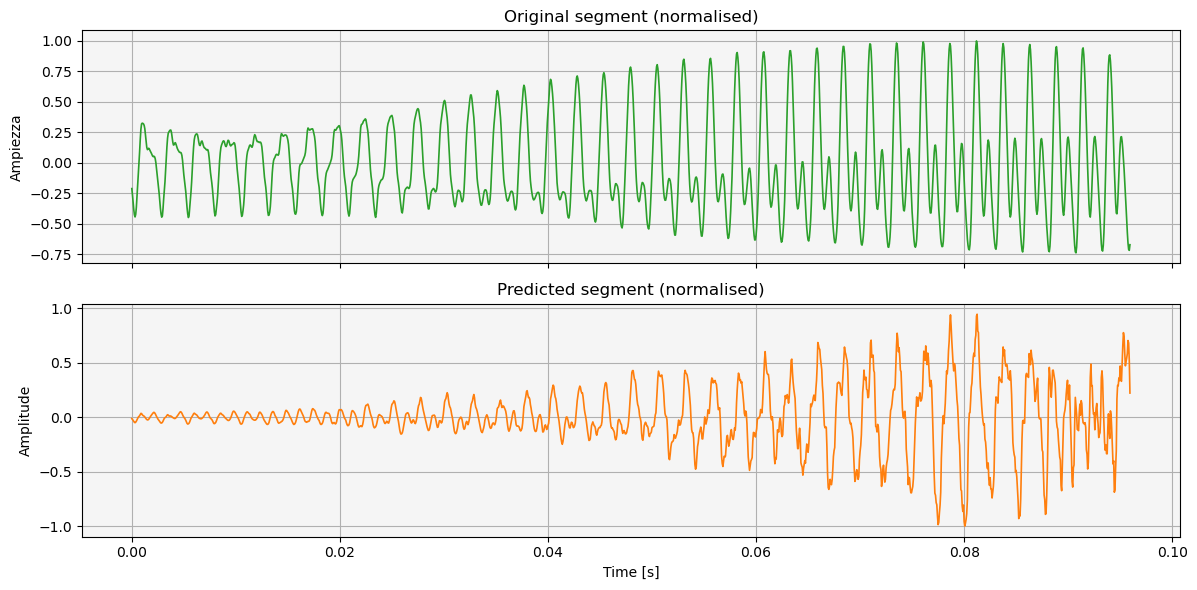

In [30]:
time_axis = np.arange(pred_chunk_audio.shape[0]) / meta['sr']
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time_axis, ref_chunk_audio, color='tab:green', lw=1.2)
axes[0].set_title('Original segment (normalised)')
axes[0].set_ylabel('Ampiezza')
axes[1].plot(time_axis, pred_chunk_audio, color='tab:orange', lw=1.2)
axes[1].set_title('Predicted segment (normalised)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()


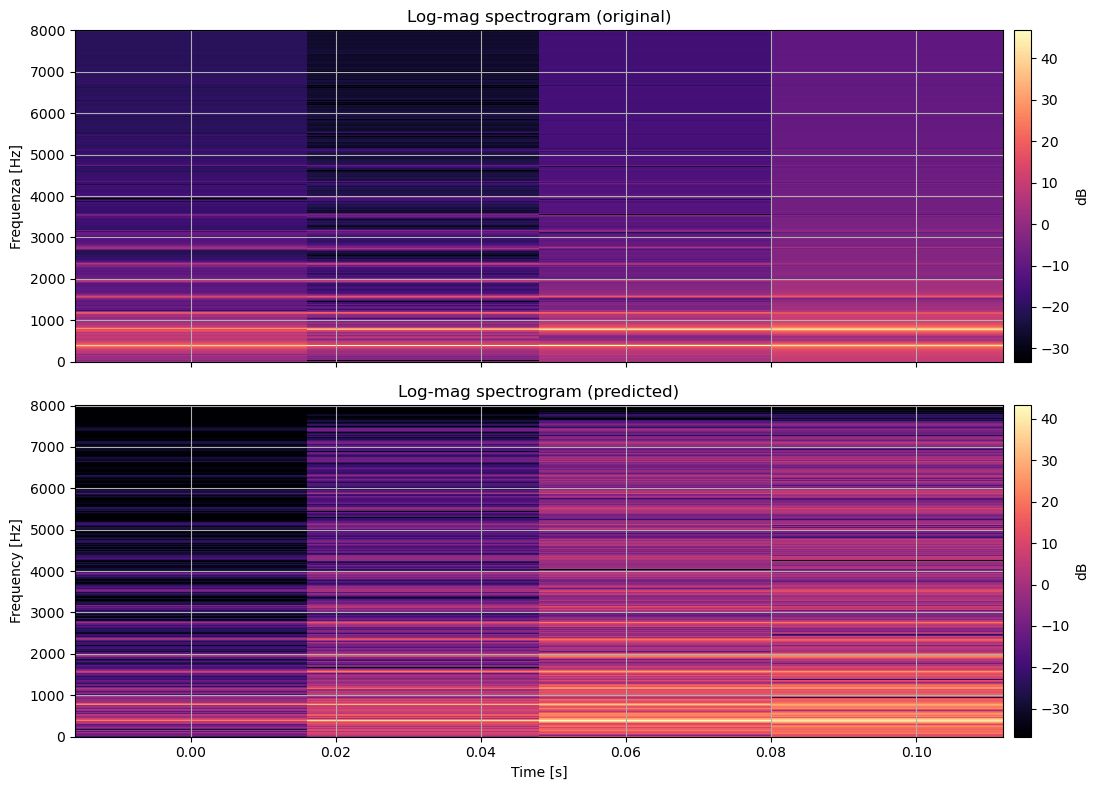

In [29]:
S_ref, t_ref, f_ref = compute_logmag_spectrogram(
    ref_chunk_audio,
    meta['sr'],
    n_fft=meta['n_fft'],
    hop_length=meta['hop'],
    win_length=meta['win_length'],
    center=False,
)
S_pred, t_pred, f_pred = compute_logmag_spectrogram(
    pred_chunk_audio,
    meta['sr'],
    n_fft=meta['n_fft'],
    hop_length=meta['hop'],
    win_length=meta['win_length'],
    center=False,
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
im0 = axes[0].pcolormesh(t_ref, f_ref, S_ref, shading='auto', cmap='magma')
axes[0].set_title('Log-mag spectrogram (original)')
axes[0].set_ylabel('Frequenza [Hz]')
fig.colorbar(im0, ax=axes[0], pad=0.01, label='dB')
im1 = axes[1].pcolormesh(t_pred, f_pred, S_pred, shading='auto', cmap='magma')
axes[1].set_title('Log-mag spectrogram (predicted)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
fig.colorbar(im1, ax=axes[1], pad=0.01, label='dB')
plt.tight_layout()
plt.show()
